# 3. Generalized temporal entropies

Rotating the space-time network by $90^\circ$ turns it into a spatial transfer matrix $\mathcal{E}$ acting on temporal
matrix product states (tMPS). Here we compute the quantity that controls the whole transverse contraction (the generalized temporal entropy) and study how it depends on the MPO construction and on the evolution time.

This notebook is a direct continuation of notebooks 1–2: same model, same $|X+\rangle$ quench, now
viewed in the rotated (temporal) picture.

## From the transfer matrix to the temporal entropy

After the rotation, the two boundary columns of the network are temporal MPS $\langle L|$ and
$|R\rangle$, which are the dominant left/right eigenvectors of $\mathcal{E}$. Because $\mathcal{E}$ is
non-Hermitian (the FSM is upper-triangular, notebook 2), the two differ and must be found
independently with the left–right power method (`powermethod_lr`). The object that captures the
overlap we actually want, $\langle L|R\rangle$, is the Reduced Transition Matrix (RTM)

$$ \mathcal{T}_t \propto |R\rangle\langle L|, $$

a non-Hermitian, unit-trace operator built jointly from the two boundaries (not a density matrix, which would use $|L\rangle\langle L|$). Its spectrum defines a family of generalized temporal
entropies. The von Neumann member $S_1^{\rm gen}=-\mathrm{Tr}(\mathcal{T}_t\log\mathcal{T}_t)$
requires the full (exponentially large) eigenspectrum and suffers from other subtleties. Therefore, we instead use the Rényi-2 member,

$$ S_2^{\rm gen}(t) = -\log \mathrm{Tr}(\mathcal{T}_t^2), $$

which needs neither a diagonalization nor a logarithm (just two copies of the RTM contracted together )
making it more efficient and numerically robust for the asymmetric Alcaraz transfer matrix.

Because $\mathcal{T}_t$ is non-Hermitian, $S_2^{\rm gen}$ is generally complex. We thus plot the real
and imaginary parts separately against the normalized temporal cut $t/T$. Its importance is that it
sets the cost of the contraction: at a critical point, CFT predicts it grows only logarithmically
in time, which is what makes the transverse method efficient (see notebooks 6–7).

**Important note:** Throughout, $\langle L|R\rangle$ is the *bilinear*
`overlap_noconj(L, R)`, not the usual `inner(L, R)`, which would conjugate the bra. 

In [1]:
include("../src/thesislib.jl")

plot_panels (generic function with 1 method)

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607

[PM LR|RTM] L=34, cutoff=1.0e-12, maxdim=256, normalize=overlap)   3%  ETA: 0:02:44 (21.22 ms/it)
   Info: [266]  chi=6 | ds=1.2447459777353842e-6 | <R|Rprev> = NaN

[ Info: PM Converged after 267 steps | ds=9.83049043390416e-7 | chi=6)


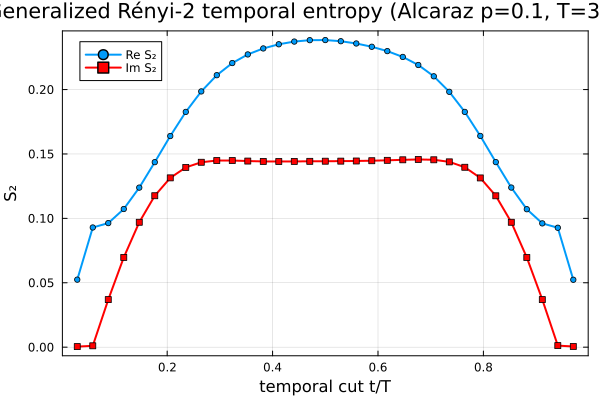

In [2]:
mp = AlcarazParams(lambda=1.0, p=0.1)
res = compute_entropies(mp, 3.0, scheme=AlcarazVD2(), dt=0.1, nbeta=4, maxdim=256)

plot(res.bonds ./ (length(res.bonds)+1), res.re; label="Re S₂", lw=2, marker=:circle, ms=3,
     xlabel="temporal cut t/T", ylabel="S₂", framestyle=:box, grid=true,
     title="Generalized Rényi-2 temporal entropy (Alcaraz p=0.1, T=3, VD2)")
plot!(res.bonds ./ (length(res.bonds)+1), res.im; label="Im S₂", lw=2, marker=:square, ms=3, color=:red)

Sweeping the final time $T$ traces out the entropy profile as a function of the temporal cut. At a
critical point, the profile takes the universal shape
$\propto \log[(2T/\pi)\sin(\pi t/T)]$, peaked at mid-cut and growing logarithmically with $T$. The
library's `plot_entropy_profiles` overlays several $T$ in one figure.

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607

[PM LR|RTM] L=69, cutoff=1.0e-12, maxdim=256, normalize=overlap)  68%  ETA: 0:03:33 (84.16 ms/it)
   Info: [5469]  chi=11 | ds=0.00034156223277648223 | <R|Rprev> = NaN

┌ Warning: PM Stuck after 2001/5470 steps | ds=0.0002873809129343985 | chi=10)
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/power_method/pm.jl:151

entropy profiles (AlcarazVD2)... 100%|███████████████████| Time: 0:19:05


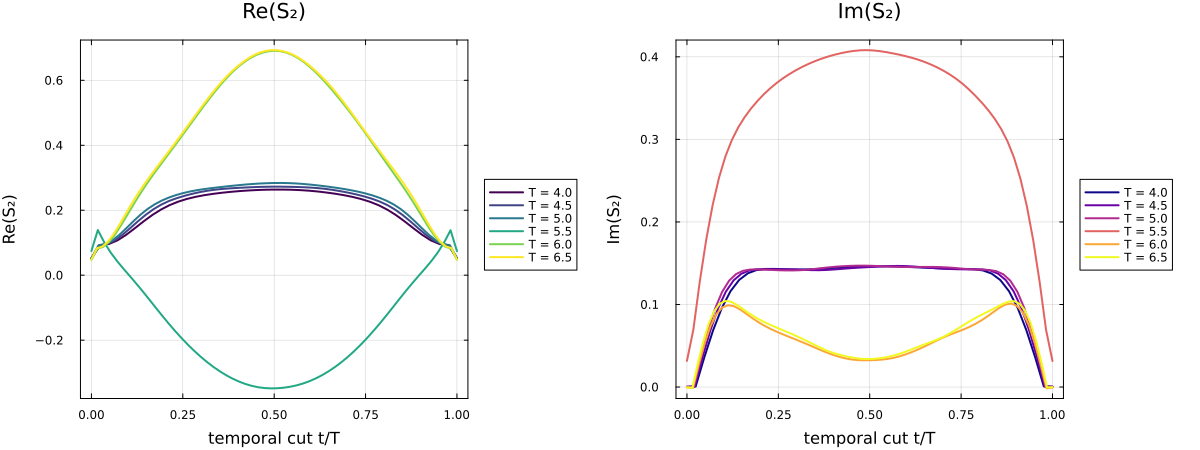

In [3]:
# Single-vector power method (use_block_pm=false): one powermethod_lr run per T
mp = AlcarazParams(lambda=1.0, p=0.1)
plot_entropy_profiles(mp, [4.0, 4.5, 5.0, 5.5, 6.0, 6.5]; scheme=AlcarazVD2(), dt=0.1, nbeta=4, maxdim=256)

## The power method stops converging at a certain $T$

The profiles above are clean conformal domes at small $T$ but fall apart for $T\gtrsim5$. This is not due to the physics, but to the single-vector power method not being able to converge. As $T$
grows, the two leading transfer-matrix eigenvalues approach each other (gap closing). 

Then, `powermethod_lr` cannot separate the dominant eigenvector from the subdominant one, stalls before `eps_converged`, and returns a contaminated $(\langle L|,|R\rangle)$ pair whose Rényi-2 profile no longer follows the expected CFT behaviour. We suspect that increasing `itermax`/`stuck_after` only delays the wall.

The gap closing can be thought of as a manifestation of the entanglement barrier (although this must be taken with care, given the formal definion of entanglement barrier). In order to overcome this, we propose a subspace (block) power method which behaves well at the gap closing and still returns the leading eigenvalues and a bi-orthonormal leading $(\langle L|,|R\rangle)$ pair.

The next cell reruns the same sweep through the block method to see the difference.

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=813|"S=1/2,Site") <-> (dim=2|id=813|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=20|"Link,l=1") <-> (dim=7|id=147|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=568|"S=1/2,Site") <-> (dim=2|id=568|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=643|"Link,l=1") <-> (d

[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=42|"Link,l=1") <-> (dim=7|id=773|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=565|"S=1/2,Site") <-> (dim=2|id=565|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=976|"Link,l=1") <-> (dim=7|id=471|"Link,l=2"), normdiff = 1.4350175351861996
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93

entropy profiles (AlcarazVD2)...  33%|██████▍            |  ETA: 0:03:53

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=313|"S=1/2,Site") <-> (dim=2|id=313|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=512|"Link,l=1") <-> (dim=7|id=182|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=741|"S=1/2,Site") <-> (dim=2|id=741|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=668|"Link,l=1") <-> (

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=433|"S=1/2,Site") <-> (dim=2|id=433|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=616|"Link,l=1") <-> (dim=7|id=311|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=857|"S=1/2,Site") <-> (dim=2|id=857|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=30|"Link,l=1") <-> (d

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=677|"S=1/2,Site") <-> (dim=2|id=677|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=104|"Link,l=1") <-> (dim=7|id=814|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=283|"S=1/2,Site") <-> (dim=2|id=283|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=611|"Link,l=1") <-> (

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=304|"S=1/2,Site") <-> (dim=2|id=304|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=591|"Link,l=1") <-> (dim=7|id=285|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=649|"S=1/2,Site") <-> (dim=2|id=649|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=349|"Link,l=1") <-> (

entropy profiles (AlcarazVD2)... 100%|███████████████████| Time: 0:22:02


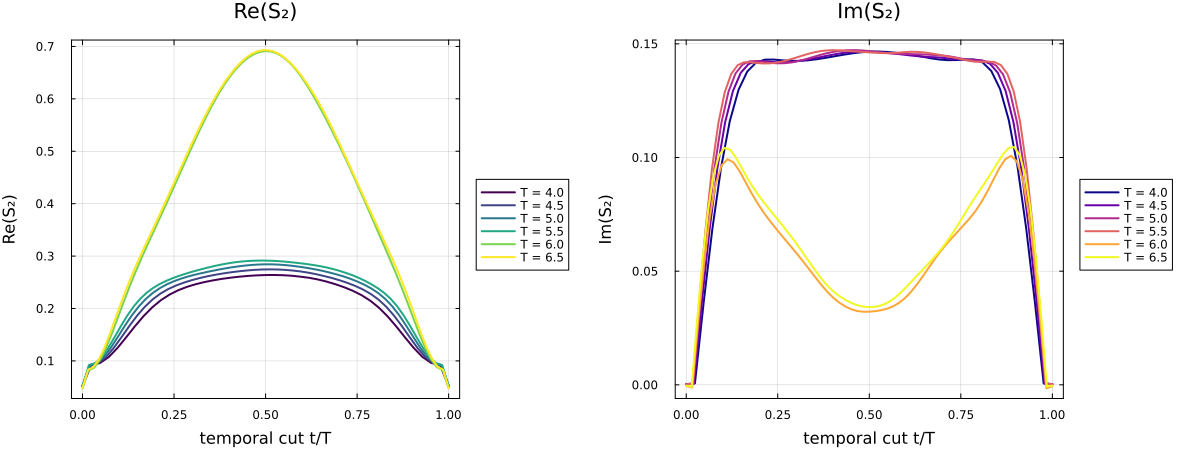

In [4]:
# Same sweep through the block power method (use_block_pm=true)
mp = AlcarazParams(lambda=1.0, p=0.1)
plot_entropy_profiles(mp, [4.0, 4.5, 5.0, 5.5, 6.0, 6.5]; scheme=AlcarazVD2(), dt=0.1, nbeta=4,
                      maxdim=256, use_block_pm=true, k_block=2)

We observe that the entropy profiles computed at $T=5.5$ with the single-vector PM and the block PM are different: the later manages to correctly capture the physics (CFT prediction), while the former one gives nonsense (due to non-convergence). The block PM manages to push the critical $T$ where the method breaks to higher times, but still fails.

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607

[PM LR|RTM] L=59, cutoff=1.0e-12, maxdim=256, normalize=overlap)  27%  ETA: 0:05:20 (54.46 ms/it)
   Info: [2122]  chi=10 | ds=0.029953854208926378 | <R|Rprev> = NaN

┌ Warning: PM Stuck after 2001/2123 steps | ds=0.030196457939789423 | chi=10)
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/power_method/pm.jl:151
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=296|"S=1/2,Site") <-> (dim=2|id=296|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=157|"Link,l=1") <-> (dim=7|id=125|"Link,l=2"), normdiff = 1.1566412865695994
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=366|"S=1/2,Site") <-> (dim=2|id=366|"S=1/2,Site")', normdiff = 0.2034249757191385
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/it

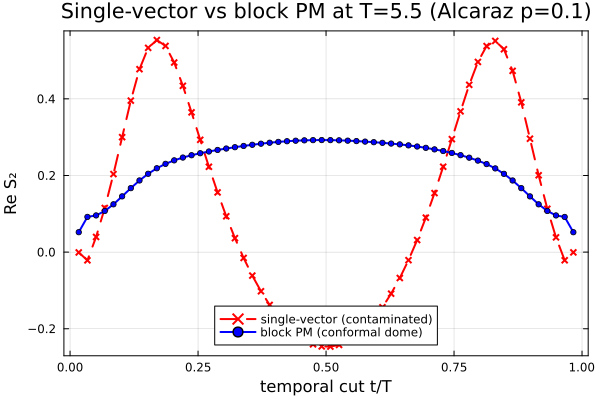

In [5]:
# compare both methods results at T=5.5
mp = AlcarazParams(lambda=1.0, p=0.1); T = 5.5

r1 = compute_entropies(mp, T; scheme=AlcarazVD2(), dt=0.1, nbeta=4, maxdim=256, use_block_pm=false)
r2 = compute_entropies(mp, T; scheme=AlcarazVD2(), dt=0.1, nbeta=4, maxdim=256, use_block_pm=true)

x1 = r1.bonds ./ (length(r1.bonds)+1); x2 = r2.bonds ./ (length(r2.bonds)+1)
plt = plot(xlabel="temporal cut t/T", ylabel="Re S₂", framestyle=:box, grid=true, legend=:bottom,
           title="Single-vector vs block PM at T=$T (Alcaraz p=0.1)")
plot!(plt, x1, r1.re; label="single-vector (contaminated)", lw=2, ls=:dash, color=:red, marker=:x, ms=3)
plot!(plt, x2, r2.re; label="block PM (conformal dome)",    lw=2, color=:blue, marker=:circle, ms=3)

## How does frustration $p$ affect the barrier?

So far everything has been at a single point, $p=0.1$. A natural next question: does the same story (the transfer-matrix gap closing) generalize to other values of the frustration $p$, and does it get worse (or better) as $p$ grows?

To answer this, we need to compute explicitly the gap between the leading two distinct eigenvalues of the transfer matrix, $|\lambda_1|/|\lambda_0|$. As this ratio approaches $1$, the power method loses its ability to separate the dominant eigenvector from the next one.

One important note (for the Alcaraz model and maybe to others too): the transfer-matrix spectrum comes in ± pairs (the physical $\lambda_0$ and a
"$-\lambda_0$ partner" that sits $\approx\pi$ away in phase at nearly the same modulus). The naive
ratio of the two largest-modulus eigenvalues measures the splitting within that pair, not a gap between genuinely distinct states, so we track $\lambda_0$ by continuity instead (following the
eigenvalue closest to the previous step's value) and skip the partner when computing the gap. Check NB5 for full details.

In [ ]:
using Printf

# The transfer-matrix spectrum comes in ± pairs. We track λ0 by continuity: at each new T,
# we keep whichever of the two largest-modulus eigenvalues is closest (as a complex number) to the
# previous step's physical value. We then define the physical gap as the ratio between λ0 and the
# next distinct eigenvalue, explicitly skipping its ± partner.
function pick_physical_eigenvalue(theta_values, previous_physical_value)
    if previous_physical_value === nothing
        return (1, 2)
    end

    distance_to_first = abs(theta_values[1] - previous_physical_value)
    distance_to_second = abs(theta_values[2] - previous_physical_value)

    if distance_to_first <= distance_to_second
        return (1, 2)
    else
        return (2, 1)
    end
end

function physical_gap_ratio(theta_values, physical_index, partner_index)
    other_indices = [j for j in eachindex(theta_values) if j != physical_index && j != partner_index]

    lambda0_modulus = abs(theta_values[physical_index])
    lambda1_modulus = isempty(other_indices) ? 0.0 : maximum(abs(theta_values[j]) for j in other_indices)

    if lambda0_modulus < 1e-30
        return 0.0
    else
        return lambda1_modulus / lambda0_modulus
    end
end

# A cheaper block-PM budget for this exploratory notebook
block_pm_settings = (
    k = 4,
    maxdim = 64,
    maxdims = collect(2:2:64),
    cutoff = 1e-12,
    cutoffs = [fill(1e-8, 40); 1e-10],
    itermax = 2000,
    eps_conv = 1e-6,
    trunc_mode = :rtm,
    n_track = 2,
    stuck_after = 150,
)

# A single (p, T) point (cold started)
function physical_gap_point(p, T; dt = 0.1, nbeta = 4, MPO_alg = "VD2")
    mpo, scaffold = build_alcaraz_tmpo(T; p = p, lambda = 1.0, dt = dt, nbeta = nbeta, MPO_alg = MPO_alg)
    half_nbeta = nbeta ÷ 2
    trim_cooling_bonds(entropy_series) = collect(entropy_series[half_nbeta+1:end-half_nbeta])

    walltime = @elapsed (theta, left_block, right_block, info) = block_transfer_eigs(
        mpo,
        scaffold;
        k = block_pm_settings.k,
        maxdim = block_pm_settings.maxdim,
        maxdims = block_pm_settings.maxdims,
        cutoff = block_pm_settings.cutoff,
        cutoffs = block_pm_settings.cutoffs,
        itermax = block_pm_settings.itermax,
        eps_conv = block_pm_settings.eps_conv,
        trunc_mode = block_pm_settings.trunc_mode,
        n_track = block_pm_settings.n_track,
        stuck_after = block_pm_settings.stuck_after,
    )

    physical_index, partner_index = pick_physical_eigenvalue(theta, nothing)
    entropy_profile = trim_cooling_bonds(ITransverse.gen_renyi2(left_block[physical_index], right_block[physical_index]))

    return (
        ; p,
        T,
        dt,
        nbeta,
        MPO_alg,
        theta = collect(theta),
        physical_index,
        partner_index,
        gap = physical_gap_ratio(theta, physical_index, partner_index),
        entropy_re = real.(entropy_profile),
        entropy_im = imag.(entropy_profile),
        peak_entropy = maximum(real.(entropy_profile)),
        reason = string(info[:reason]),
        niters = info[:niters],
        max_bond_dim = max(maxlinkdim(left_block[physical_index]), maxlinkdim(right_block[physical_index])),
        n_time_steps = length(entropy_profile) + 1,
        walltime,
    )
end

# Warm-started T-ladder for one value of p (or one MPO kernel): each new T reuses the previous T's
# converged block as its starting guess (via pad_tmps), which is both cheaper and more stable than
# a cold start.

function physical_gap_ladder(p, T_values; dt = 0.1, nbeta = 4, MPO_alg = "VD2")
    results = Dict{Float64,Any}()
    previous_left_block = nothing
    previous_right_block = nothing
    previous_physical_value = nothing
    half_nbeta = nbeta ÷ 2
    trim_cooling_bonds(entropy_series) = collect(entropy_series[half_nbeta+1:end-half_nbeta])

    for T in sort(collect(Float64.(T_values)))
        mpo, scaffold = build_alcaraz_tmpo(T; p = p, lambda = 1.0, dt = dt, nbeta = nbeta, MPO_alg = MPO_alg)
        scaffold_sites = siteinds(scaffold)
        seed_left = previous_left_block === nothing ? nothing : MPS[pad_tmps(w, scaffold_sites) for w in previous_left_block]
        seed_right = previous_right_block === nothing ? nothing : MPS[pad_tmps(w, scaffold_sites) for w in previous_right_block]

        theta, left_block, right_block, info = block_transfer_eigs(
            mpo,
            scaffold;
            k = block_pm_settings.k,
            maxdim = block_pm_settings.maxdim,
            maxdims = block_pm_settings.maxdims,
            cutoff = block_pm_settings.cutoff,
            cutoffs = block_pm_settings.cutoffs,
            itermax = block_pm_settings.itermax,
            eps_conv = block_pm_settings.eps_conv,
            trunc_mode = block_pm_settings.trunc_mode,
            n_track = block_pm_settings.n_track,
            stuck_after = block_pm_settings.stuck_after,
            seedL = seed_left,
            seedR = seed_right,
        )

        physical_index, partner_index = pick_physical_eigenvalue(theta, previous_physical_value)
        entropy_profile = trim_cooling_bonds(ITransverse.gen_renyi2(left_block[physical_index], right_block[physical_index]))

        results[T] = (
            ; p,
            T,
            theta = collect(theta),
            physical_index,
            partner_index,
            gap = physical_gap_ratio(theta, physical_index, partner_index),
            entropy_re = real.(entropy_profile),
            entropy_im = imag.(entropy_profile),
            peak_entropy = maximum(real.(entropy_profile)),
            reason = string(info[:reason]),
            niters = info[:niters],
        )

        previous_physical_value = theta[physical_index]
        previous_left_block, previous_right_block = left_block, right_block
        GC.gc()
    end

    return results
end

mkpath("../results/imgs")
mkpath("../results/data")

"../results/data"

In [7]:
# One warm-started ladder per p
p_gap_cache = "../results/data/nb55_pgap.jld2"
p_values    = [0.0, 0.1, 0.3, 0.5]
T_values_p  = collect(2.0:1.0:7.0)

p_gap_results = isfile(p_gap_cache) ? load(p_gap_cache, "D") : Dict{Float64,Any}()
for p in p_values
    haskey(p_gap_results, p) && continue
    @info "physical-gap ladder for p=$p"

    p_gap_results[p] = physical_gap_ladder(p, T_values_p; dt=0.1, nbeta=4, MPO_alg="VD2")
    
    jldsave(p_gap_cache; D=p_gap_results)
    GC.gc()
end
@info "p-sweep loaded" ps=sort(collect(keys(p_gap_results)))

┌ Info: p-sweep loaded
│   ps =
│    4-element Vector{Float64}:
│     0.0
│     0.1
│     0.3
└     0.5


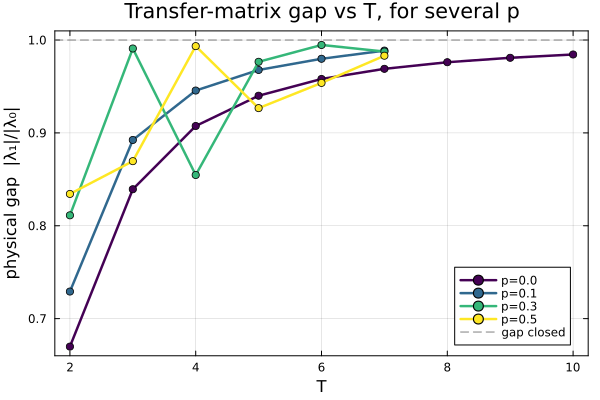

In [8]:
# Physical gap vs T, one curve per p
colors_by_p = cgrad(:viridis, length(p_values), categorical=true)
gap_plot = plot(xlabel="T", ylabel="physical gap  |λ₁|/|λ₀|", framestyle=:box, grid=true,
                legend=:bottomright, title="Transfer-matrix gap vs T, for several p")

for (i, p) in enumerate(p_values)
    T_sorted = sort(collect(keys(p_gap_results[p])))
    gap_values = [p_gap_results[p][T].gap for T in T_sorted]
    
    plot!(gap_plot, T_sorted, gap_values; label="p=$p", lw=2.5, marker=:circle, ms=4, color=colors_by_p[i])
end

hline!(gap_plot, [1.0]; ls=:dash, color=:gray, label="gap closed")
savefig(gap_plot, "../results/imgs/nb55_p_gap.png")
gap_plot

p    | T_crit (first non-converged) | reason per T


─────┼──────────────────────────────┼────────────────────────
0.0  | 5.0                          | conv conv conv stuc stuc stuc stuc stuc stuc
0.1  | 3.0                          | conv stuc conv stuc stuc stuc


0.3  | 5.0                          | conv conv conv stuc stuc conv
0.5  | 4.0                          | conv conv stuc conv stuc stuc


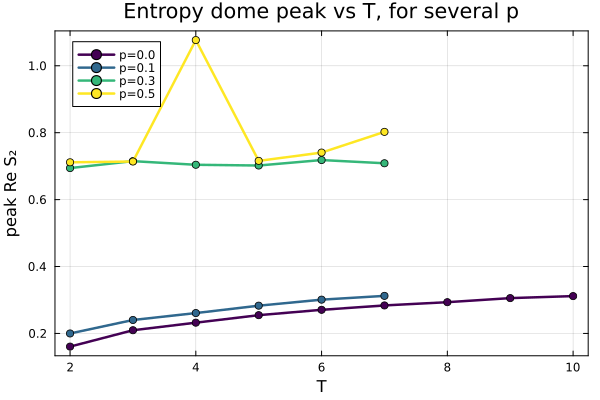

In [9]:
# Entropy-dome peak vs T, one curve per p, plus a table of T_crit(p)
peak_plot = plot(xlabel="T", ylabel="peak Re S₂", framestyle=:box, grid=true, legend=:topleft,
                 title="Entropy dome peak vs T, for several p")
for (i, p) in enumerate(p_values)
    T_sorted = sort(collect(keys(p_gap_results[p])))
    peak_values = [p_gap_results[p][T].peak for T in T_sorted]
    plot!(peak_plot, T_sorted, peak_values; label="p=$p", lw=2.5, marker=:circle, color=colors_by_p[i])
end
savefig(peak_plot, "../results/imgs/nb55_p_peak.png")

println("p    | T_crit (first non-converged) | reason per T")
println("─────┼──────────────────────────────┼────────────────────────")
for p in p_values
    T_sorted = sort(collect(keys(p_gap_results[p])))
    first_non_converged = findfirst(T -> p_gap_results[p][T].reason != "converged", T_sorted)
    T_crit = first_non_converged === nothing ? Inf : T_sorted[first_non_converged]
    reasons_short = join([p_gap_results[p][T].reason[1:min(4,end)] for T in T_sorted], " ")
    @printf("%-4.1f | %-28s | %s\n", p, string(T_crit), reasons_short)
end
peak_plot

For $p=0.3$ and $p=0.5$ the gap oscillates, indicating an error. Possible causes are:
- *Selector sensitivity.* `pick_physical_eigenvalue` only ever chooses between the two
  largest-modulus eigenvalues (indices 1 and 2, since `block_transfer_eigs` always returns them
  sorted by modulus). An unrestricted version (searching all four candidates for whichever is
  closest to the previous step's value) genuinely picks a *different* index at several $T$, so the
  restriction is not innocuous. But its resulting "gap" exceeds $1$ at some of those points, which is
  impossible for a real dominant/subdominant pair: the unrestricted selector is tracking a
  *subdominant* branch, not a better one. So this shows the selection is fragile here, without
  handing us a validated fix.
- *Under-convergence.* This sweep uses a cheaper iteration budget than notebook 7's production
  sweep (`itermax=2000` vs `8000`, to make a 4-point $p$-sweep affordable at all).

So frustration clearly makes the barrier harder to track numerically as well as physically. Investigating how we can solve this is left as an open item (see next section).

### Fixing the physical selector

We found that `pick_physical_eigenvalue` only ever compares the two *largest-modulus* eigenvalues (indices 1 and 2, since `block_transfer_eigs` returns them sorted by modulus), and `physical_gap_ratio` assumes there is exactly one "$-\lambda_0$ partner" to skip.

Looking at the raw spectra directly, each eigenvalue naturally falls into one of two classes, distinguished by its *phase* relative to $\lambda_0$ (not its modulus rank):

- the *"tower"*: $\lambda_0$ itself and its physical CFT descendants, all with a phase close to $\lambda_0$'s;
- the *"partners"*: states shifted by $\approx\pi$ in phase from some tower member, at nearly the same modulus.

At $p=0$, the leading block has *no* partners at all. For $p>0$, two or more partner-class states appear in the same $k=4$ block, and, critically, can move to the tower as $T$ grows. A selector that only ever looks at indices 1 and 2 will therefore often grab a partner instead of the true $\lambda_1$, and occasionally (at $p=0.3$, $T=4$) the block is *entirely* partners plus $\lambda_0$ (with $\lambda_1$ pushed out of the $k=4$ window altogether).

The fix is to classify by phase instead of by rank.

In [ ]:
# the "physical" phase of an eigenvalue is angle(-eigenvalue)
physical_phase(eigenvalue) = angle(-eigenvalue)

# Phase of eigenvalue_a relative to eigenvalue_b, wrapped into (-π, π] so that +π and -π agree
function wrapped_phase_difference(eigenvalue_a, eigenvalue_b)
    raw_difference = physical_phase(eigenvalue_a) - physical_phase(eigenvalue_b)
    return mod(raw_difference + pi, 2 * pi) - pi
end

# Split a block of eigenvalues into the λ0-tower (λ0 itself plus its physical CFT descendants) and
# its ±π partners, using phase alone (improved veresion of old pick_physical_eigenvalue/physical_gap_ratio)
function classify_spectrum(eigenvalues)
    lambda0_index = argmax(abs.(eigenvalues))

    tower_indices = Int[]
    partner_indices = Int[]
    for j in eachindex(eigenvalues)
        phase_gap = wrapped_phase_difference(eigenvalues[j], eigenvalues[lambda0_index])
        if abs(phase_gap) < pi / 2
            push!(tower_indices, j)
        else
            push!(partner_indices, j)
        end
    end

    tower_descendants = [j for j in tower_indices if j != lambda0_index]
    if isempty(tower_descendants)
        # λ1 was not captured in this block at all (need a bigger k)
        tower_gap = NaN
    else
        lambda1_modulus = maximum(abs(eigenvalues[j]) for j in tower_descendants)
        tower_gap = lambda1_modulus / abs(eigenvalues[lambda0_index])
    end

    return (; lambda0_index, tower_indices, partner_indices, tower_gap)
end

classify_spectrum (generic function with 1 method)

In [ ]:
# Apply the classifier to the k=4 cache already computed above (p_gap_results).
# stored = old blind gap; tower = corrected one.
# A "—" in the tower column means λ1 was  missing from this k=4 block.
println("Per-(p,T) spectrum anatomy, k=4 cache (block_pm_settings, itermax=2000)\n")
for p in p_values
    @printf("──── p = %.1f ────\n", p)
    @printf("  %-4s │ %-8s │ %-8s │ #tower  #partner\n", "T", "stored", "tower")
    for T in sort(collect(keys(p_gap_results[p])))
        entry = p_gap_results[p][T]
        classification = classify_spectrum(entry.theta)
        tower_gap_string = isnan(classification.tower_gap) ? "  —   " : @sprintf("%.4f", classification.tower_gap)
        @printf("  %-4.1f │ %-8.4f │ %-8s │ %d       %d\n",
                T, entry.gap, tower_gap_string,
                length(classification.tower_indices), length(classification.partner_indices))
    end
    println()
end

Per-(p,T) spectrum anatomy, k=4 cache (block_pm_settings, itermax=2000)

──── p = 0.0 ────
  T    │ stored   │ tower    │ #tower  #partner


  2.0  │ 0.6699   │ 0.8897   │ 4       0
  3.0  │ 0.8393   │ 0.9466   │ 4       0


  4.0  │ 0.9074   │ 0.9688   │ 4       0
  5.0  │ 0.9401   │ 0.9793   │ 4       0
  6.0  │ 0.9581   │ 0.9853   │ 4       0
  7.0  │ 0.9690   │ 0.9888   │ 4       0
  8.0  │ 0.9761   │ 0.9911   │ 4       0
  9.0  │ 0.9809   │ 0.9927   │ 4       0
  10.0 │ 0.9845   │ 0.9939   │ 4       0

──── p = 0.1 ────
  T    │ stored   │ tower    │ #tower  #partner
  2.0  │ 0.7291   │ 0.6512   │ 2       2
  3.0  │ 0.8924   │ 0.8644   │ 2       2
  4.0  │ 0.9456   │ 0.9352   │ 2       2
  5.0  │ 0.9678   │ 0.9648   │ 2       2
  6.0  │ 0.9799   │ 0.9780   │ 2       2
  7.0  │ 0.9887   │ 0.9826   │ 2       2

──── p = 0.3 ────
  T    │ stored   │ tower    │ #tower  #partner
  2.0  │ 0.8112   │ 0.8112   │ 2       2
  3.0  │ 0.9909   │ 0.9211   │ 2       2
  4.0  │ 0.8547   │   —      │ 1       3
  5.0  │ 0.9766   │ 0.9731   │ 2       2
  6.0  │ 0.9947   │ 0.9894   │ 2       2
  7.0  │ 0.9876   │ 0.9876   │ 2       2

──── p = 0.5 ────
  T    │ stored   │ tower    │ #tower  #partner
  2.0  │ 0.8343   │ 

Reclassifying already fixes most of the erratic behaviour

One point is missing ($p=0.3$, $T=4$): the entire $k=4$ block is $\lambda_0$ plus three partners ($\lambda_1$ was never captured). The cell below repeats those specific $(p,T)$ points with $k=6$ instead of $k=4$:

In [ ]:
# k=6 cross-check at the fast points (T=2,3,4) for all four p.
k6_gap_cache = "../results/data/nb3_gap_k6.jld2"
k6_results = isfile(k6_gap_cache) ? load(k6_gap_cache, "done") : Dict{Any,Any}()

k6_settings = merge(block_pm_settings, (k=6, itermax=1000, stuck_after=120))
T_values_k6 = [2.0, 3.0, 4.0]

for p in p_values
    previous_left_block = nothing
    previous_right_block = nothing
    for T in T_values_k6
        cache_key = (:k6, p, T)
        if haskey(k6_results, cache_key) && !haskey(k6_results[cache_key], :error)
            previous_left_block = nothing   # a cached point carries no stored vectors to warm-start from
            previous_right_block = nothing
            continue
        end

        mpo, scaffold = build_alcaraz_tmpo(T; p=p, lambda=1.0, dt=0.1, nbeta=4, MPO_alg="VD2")
        scaffold_sites = siteinds(scaffold)
        seed_left = previous_left_block === nothing ? nothing :
            MPS[pad_tmps(w, scaffold_sites) for w in previous_left_block]
        seed_right = previous_right_block === nothing ? nothing :
            MPS[pad_tmps(w, scaffold_sites) for w in previous_right_block]

        theta, left_block, right_block, info = block_transfer_eigs(
            mpo, scaffold;
            k=k6_settings.k, maxdim=k6_settings.maxdim, maxdims=k6_settings.maxdims,
            cutoff=k6_settings.cutoff, cutoffs=k6_settings.cutoffs,
            itermax=k6_settings.itermax, eps_conv=k6_settings.eps_conv,
            trunc_mode=k6_settings.trunc_mode, n_track=k6_settings.n_track,
            stuck_after=k6_settings.stuck_after, seedL=seed_left, seedR=seed_right,
        )

        k6_results[cache_key] = (theta=collect(theta), reason=string(info[:reason]), niters=info[:niters])
        jldsave(k6_gap_cache; done=k6_results)
        previous_left_block, previous_right_block = left_block, right_block
        GC.gc()
    end
end

n_k6_points = count(key -> key[1] == :k6, collect(keys(k6_results)))
@info "k=6 cross-check loaded" n_k6_points

┌ Info: k=6 cross-check loaded
└   n_k6_points = 17


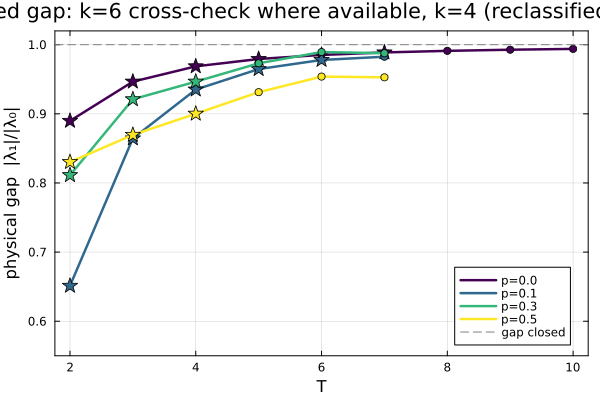

In [ ]:
# Corrected gap plot: k=6 (star markers) where available, k=4 reclassified (circle markers) everywhere else
corrected_gap_plot = plot(xlabel="T", ylabel="physical gap  |λ₁|/|λ₀|", framestyle=:box, grid=true,
                          legend=:bottomright, ylims=(0.55, 1.02),
                          title="Corrected gap: k=6 cross-check where available, k=4 (reclassified) otherwise")

for (i, p) in enumerate(p_values)
    T_sorted = sort(collect(keys(p_gap_results[p])))

    gap_values = Float64[]
    used_k6 = Bool[]
    
    for T in T_sorted
        k6_key = (:k6, p, T)
        if haskey(k6_results, k6_key)
            push!(gap_values, classify_spectrum(k6_results[k6_key].theta).tower_gap)
            push!(used_k6, true)
        else
            push!(gap_values, classify_spectrum(p_gap_results[p][T].theta).tower_gap)
            push!(used_k6, false)
        end
    end

    plot!(corrected_gap_plot, T_sorted, gap_values; color=colors_by_p[i], lw=2.5, label="p=$p")

    k6_positions = findall(used_k6)
    scatter!(corrected_gap_plot, T_sorted[k6_positions], gap_values[k6_positions];
             color=colors_by_p[i], marker=:star5, ms=8, label="")

    k4_positions = findall(.!used_k6)
    scatter!(corrected_gap_plot, T_sorted[k4_positions], gap_values[k4_positions];
             color=colors_by_p[i], marker=:circle, ms=4, label="")
end
hline!(corrected_gap_plot, [1.0]; ls=:dash, color=:gray, label="gap closed")

savefig(corrected_gap_plot, "../results/imgs/nb3_gap_corrected.png")
corrected_gap_plot

In [14]:
# Does the bigger block change anything at points that were already "converged" at k=4?
println("k=4 (reclassified) vs k=6 tower gap, at T=2,3,4\n")
println("  p    T    k=4 tower gap    k=6 tower gap")
for p in p_values, T in T_values_k6
    k4_gap = classify_spectrum(p_gap_results[p][T].theta).tower_gap
    k6_gap = classify_spectrum(k6_results[(:k6, p, T)].theta).tower_gap
    k4_string = isnan(k4_gap) ? "  —   " : @sprintf("%.4f", k4_gap)
    k6_string = isnan(k6_gap) ? "  —   " : @sprintf("%.4f", k6_gap)
    @printf("  %-4.1f %-4.1f  %-14s  %-14s\n", p, T, k4_string, k6_string)
end

k=4 (reclassified) vs k=6 tower gap, at T=2,3,4

  p    T    k=4 tower gap    k=6 tower gap
  0.0  2.0   0.8897          0.8898        
  0.0  3.0   0.9466          0.9466        


  0.0  4.0   0.9688          0.9687        
  0.1  2.0   0.6512          0.6513        
  0.1  3.0   0.8644          0.8644        
  0.1  4.0   0.9352          0.9352        
  0.3  2.0   0.8112          0.8113        
  0.3  3.0   0.9211          0.9211        
  0.3  4.0     —             0.9466        
  0.5  2.0   0.8303          0.8303        
  0.5  3.0   0.8696          0.8696        
  0.5  4.0   0.9002          0.9002        


Both agree everywhere except at $p=0.3$, $T=4$, where the $k=6$ run recovers a tower gap sitting exactly where we'd expect between the $T=3$ and $T=5$ values.

### What do these numbers mean physically? CFT boundary operators

Every state in the tower above $\lambda_0$ corresponds to a boundary CFT operator. Its scaling dimension $x_n$ is read directly off the phase gap to $\lambda_0$:

$$ x_n = \frac{vT}{\pi} \, |\Delta\varphi_n|, \qquad \Delta\varphi_n = \text{wrapped\_phase\_difference}(\lambda_n, \lambda_0) $$

with $v=2$ the Ising CFT velocity. 

Consider the $p=0$, $T=2$ row from the table further up: the second tower state sits at $\Delta\varphi/\pi \approx 0.113$, giving $x = (2\cdot2/\pi)\cdot0.113\pi \approx 0.45$, which matches the free-boundary Ising state $x_1=1/2$ from Eq. (4) of Carignano-Tagliacozzo. So "$\lambda_1$" is not an abstract "next eigenvalue": it is *the specific CFT operator with $x_1=1/2$*, and the tower gap $|\lambda_1|/|\lambda_0|$ is really "how close is the barrier to swallowing the $x=1/2$ boundary operator".

However, it turns out $p=0.1$ is not just "another point on the same curve" as $p=0,0.3,0.5$: its lowest tower state is a *different* $x_n$ altogether, not the $x\approx1/2$ operator the other three values of $p$ show. Comparing $|\lambda_1|/|\lambda_0|$ across $p$ is therefore only a fair comparison once you've checked you're tracking the same $x_n$ on both sides. Otherwise "the gap closes faster/slower" is comparing the barrier's approach to two different states. We work this out properly in the follow-up analysis.

## MPO scheme dependence: VD2 vs WII

From NB2, we expect VD2
(true 2nd order for NNN interactions) to be the trustworthy choice for this NNN model and WII (genuinely 1st
order here) to deviate, especially at larger $T$ where the temporal chain is long. The cell below
compares them at a fixed (short) time.

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607

[PM LR|RTM] L=54, cutoff=1.0e-12, maxdim=256, normalize=overlap)  38%  ETA: 0:01:18 (15.77 ms/it)
   Info: [3039]  chi=8 | ds=4.763765363463568e-5 | <R|Rprev> = NaN

┌ Warning: PM Stuck after 2001/3044 steps | ds=4.7637653634108323e-5 | chi=8)
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/power_method/pm.jl:151


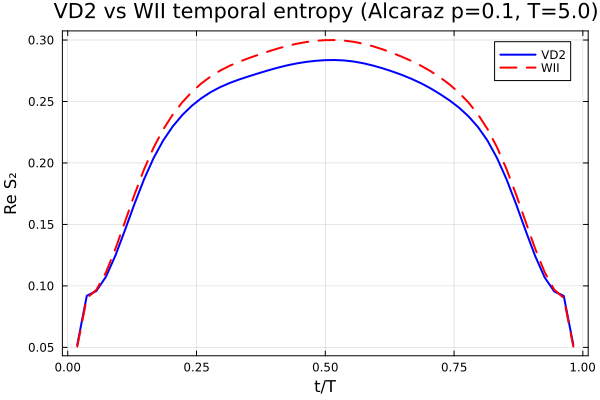

In [15]:
mp = AlcarazParams(lambda=1.0, p=0.1)
T  = 5.0

rV = compute_entropies(mp, T; scheme=AlcarazVD2(), dt=0.1, nbeta=4, maxdim=256)
rW = compute_entropies(mp, T; scheme=AlcarazWII(), dt=0.1, nbeta=4, maxdim=256)

xV = rV.bonds ./ (length(rV.bonds)+1)
xW = rW.bonds ./ (length(rW.bonds)+1)

plt = plot(xlabel="t/T", ylabel="Re S₂", framestyle=:box, grid=true,
           title="VD2 vs WII temporal entropy (Alcaraz p=0.1, T=$T)")
plot!(plt, xV, rV.re; label="VD2", lw=2, color=:blue)
plot!(plt, xW, rW.re; label="WII", lw=2, ls=:dash, color=:red)

The single check above doesn't show much difference at one $T$, but does the discrepancy between
the two kernels grow as the temporal chain gets longer? We extend to a $T$-ladder using the block
power method to see the trend.

In [16]:
# VD2 vs WII kernel ladders over T=2..6 (p=0.1)
kernel_cache = "../results/data/nb55_wii_vd2.jld2"

T_values_kernel = collect(2.0:1.0:6.0)

kernel_results = isfile(kernel_cache) ? load(kernel_cache, "D") : Dict{String,Any}()
for kernel in ["VD2", "WII"]
    haskey(kernel_results, kernel) && continue
    @info "kernel ladder: $kernel"

    kernel_results[kernel] = physical_gap_ladder(0.1, T_values_kernel; dt=0.1, nbeta=4, MPO_alg=kernel)

    jldsave(kernel_cache; D=kernel_results)
    GC.gc()
end
@info "kernel sweep loaded" kernels=sort(collect(keys(kernel_results)))

┌ Info: kernel sweep loaded
│   kernels =
│    2-element Vector{String}:
│     "VD2"
└     "WII"


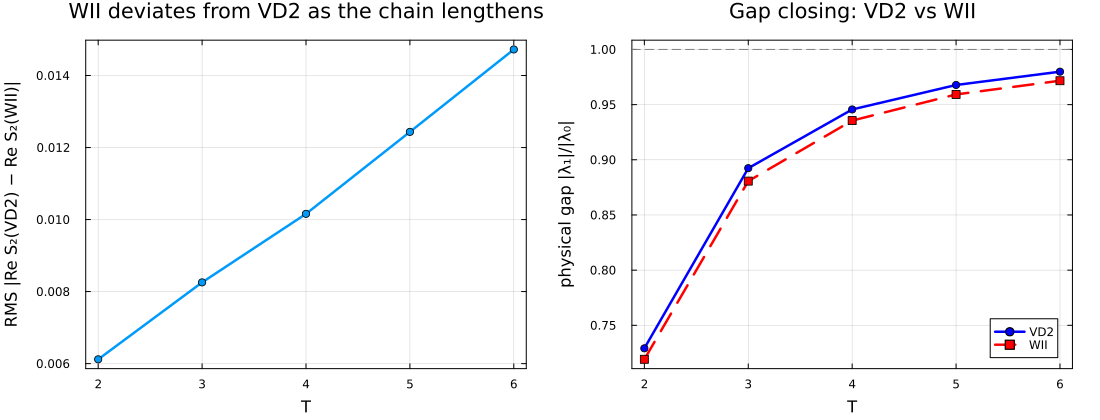

In [17]:
using LinearAlgebra: norm

# Overlay entropy profiles at a few T, then quantify how much the two kernels disagree
kernel_profile_plot = plot(
    xlabel = "t/T",
    ylabel = "Re S₂",
    framestyle = :box,
    grid = true,
    legend = :outerright,
    title = "VD2 vs WII entropy (Alcaraz p=0.1)",
)

for T in [3.0, 5.0, 6.0]
    vd2 = kernel_results["VD2"][T]
    wii = kernel_results["WII"][T]

    x_vd2 = range(0, 1, length = length(vd2.s2_re))
    x_wii = range(0, 1, length = length(wii.s2_re))

    plot!(kernel_profile_plot, x_vd2, vd2.s2_re; label = "VD2 T=$T", lw = 2)
    plot!(kernel_profile_plot, x_wii, wii.s2_re; label = "WII T=$T", lw = 2, ls = :dash)
end

savefig(kernel_profile_plot, "../results/imgs/nb55_wii_vd2_profiles.png")

T_sorted_kernel = sort(collect(keys(kernel_results["VD2"])))
rms_divergence = Float64[]

for T in T_sorted_kernel
    vd2 = kernel_results["VD2"][T]
    wii = kernel_results["WII"][T]

    n_common = min(length(vd2.s2_re), length(wii.s2_re))
    difference = vd2.s2_re[1:n_common] .- wii.s2_re[1:n_common]
    push!(rms_divergence, norm(difference) / sqrt(n_common))
end

rms_plot = plot(
    T_sorted_kernel,
    rms_divergence;
    xlabel = "T",
    ylabel = "RMS |Re S₂(VD2) − Re S₂(WII)|",
    lw = 2.5,
    marker = :circle,
    framestyle = :box,
    grid = true,
    legend = false,
    title = "WII deviates from VD2 as the chain lengthens",
)

gap_kernel_plot = plot(
    xlabel = "T",
    ylabel = "physical gap |λ₁|/|λ₀|",
    framestyle = :box,
    grid = true,
    legend = :bottomright,
    title = "Gap closing: VD2 vs WII",
)

plot!(
    gap_kernel_plot,
    T_sorted_kernel,
    [kernel_results["VD2"][T].gap for T in T_sorted_kernel];
    lw = 2.5,
    marker = :circle,
    label = "VD2",
    color = :blue,
)
plot!(
    gap_kernel_plot,
    T_sorted_kernel,
    [kernel_results["WII"][T].gap for T in T_sorted_kernel];
    lw = 2.5,
    marker = :square,
    label = "WII",
    color = :red,
    ls = :dash,
)
hline!(gap_kernel_plot, [1.0]; ls = :dash, color = :gray, label = "")

savefig(
    plot(rms_plot, gap_kernel_plot; layout = (1, 2), size = (1100, 420), margin = 5Plots.mm),
    "../results/imgs/nb55_wii_vd2_gap.png",
)

plot(rms_plot, gap_kernel_plot; layout = (1, 2), size = (1100, 420), margin = 5Plots.mm)

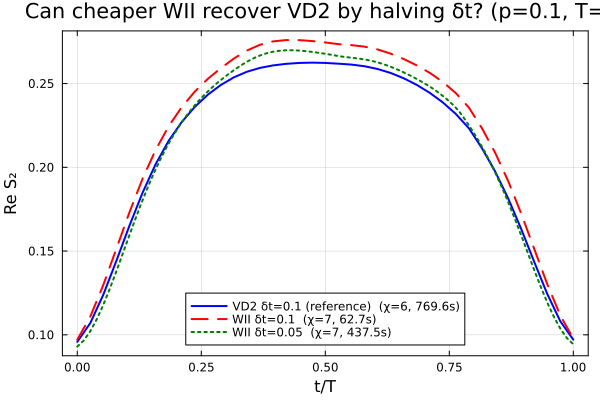

In [18]:
# Compare VD2 at δt=0.1 (reference), WII at δt=0.1, and WII at δt=0.05, all at the same T=4.
cross_check_cache = "../results/data/nb55_cross.jld2"
cross_check_results = isfile(cross_check_cache) ? load(cross_check_cache, "D") : Dict{Any,Any}()

comparison_cases = [
    ("VD2", 0.1, 4),
    ("WII", 0.1, 4),
    ("WII", 0.05, 8),
]

for (kernel, dt, nbeta) in comparison_cases
    case_key = (kernel, dt)
    haskey(cross_check_results, case_key) && continue

    cross_check_results[case_key] = physical_gap_point(
        0.1,
        4.0;
        dt = dt,
        nbeta = nbeta,
        MPO_alg = kernel,
    )
    jldsave(cross_check_cache; D = cross_check_results)
    GC.gc()
end

cross_check_plot = plot(
    xlabel = "t/T",
    ylabel = "Re S₂",
    framestyle = :box,
    grid = true,
    legend = :bottom,
    title = "Can cheaper WII recover VD2 by halving δt? (p=0.1, T=4)",
)

comparison_specs = [
    (("VD2", 0.1), "VD2 δt=0.1 (reference)", :solid, :blue),
    (("WII", 0.1), "WII δt=0.1", :dash, :red),
    (("WII", 0.05), "WII δt=0.05", :dot, :green),
]

for (key, label, style, color) in comparison_specs
    haskey(cross_check_results, key) || continue

    result = cross_check_results[key]
    x_positions = range(0, 1, length = length(result.s2_re))

    plot!(
        cross_check_plot,
        x_positions,
        result.s2_re;
        label = label * "  (χ=$(result.maxchi), $(round(result.walltime, digits = 1))s)",
        lw = 2,
        ls = style,
        color = color,
    )
end

savefig(cross_check_plot, "../results/imgs/nb55_wii_dt_cross.png")
cross_check_plot

The Root Mean Square (RMS) profile difference between VD2 and WII grows
monotonically with $T$, as expected: VD2
is unconditionally second-order for this NNN model, while WII is genuinely only first-order here (it
is only effectively second-order for strictly nearest-neighbour Hamiltonians) 

It is worth noting that WII at $\delta t=0.1$ is cheap
(converges quickly) but visibly off VD2's reference profile. Halving WII's $\delta t$ to $0.05$ moves it about halfway toward VD2 but at several times the cost. VD2 at $\delta t = 0.1$ remains the better trade-off for this frustrated model.

## Dependence on the Trotter step $\delta t$

The block PM pushes the time beyong which the PM stops converging to larger $T$. A natural question is whether
$T_{\rm crit}$ is a physical time or partly a discretization artifact: does it move when we
refine the Trotter step $\delta t$?

Here we repeat the entropy sweep at $\delta t=0.05$ and compare to the $\delta t=0.1$ figures above,
at the same physical times $T$. 

Subtle note: to hold the UV regulator $\beta_0=0.2$ fixed, we
need $N_\beta = 2\beta_0/\delta t$ cooling sites, so $\delta t=0.05 \Rightarrow$ `nbeta=8` (vs
`nbeta=4` at $\delta t=0.1$). Smaller $\delta t$ also means twice as many temporal sites for the
same $T$ (a longer tMPS), so these runs are correspondingly heavier.

### Single-vector PM: does the barrier move with $\delta t$?

First the cheap single-vector method. Compare the figure below ($\delta t=0.05$) to the
$\delta t=0.1$ single-vector sweep earlier in the notebook.

┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607

[PM LR|RTM] L=138, cutoff=1.0e-12, maxdim=256, normalize=overlap)  45%  ETA: 0:10:06 ( 0.14  s/it)
   Info: [3581]  chi=10 | ds=0.000366519150380884 | <R|Rprev> = NaN

┌ Warning: PM Stuck after 2001/3582 steps | ds=0.00036665223049958673 | chi=10)
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/power_method/pm.jl:151


entropy profiles (AlcarazVD2)... 100%|███████████████████| Time: 0:41:25


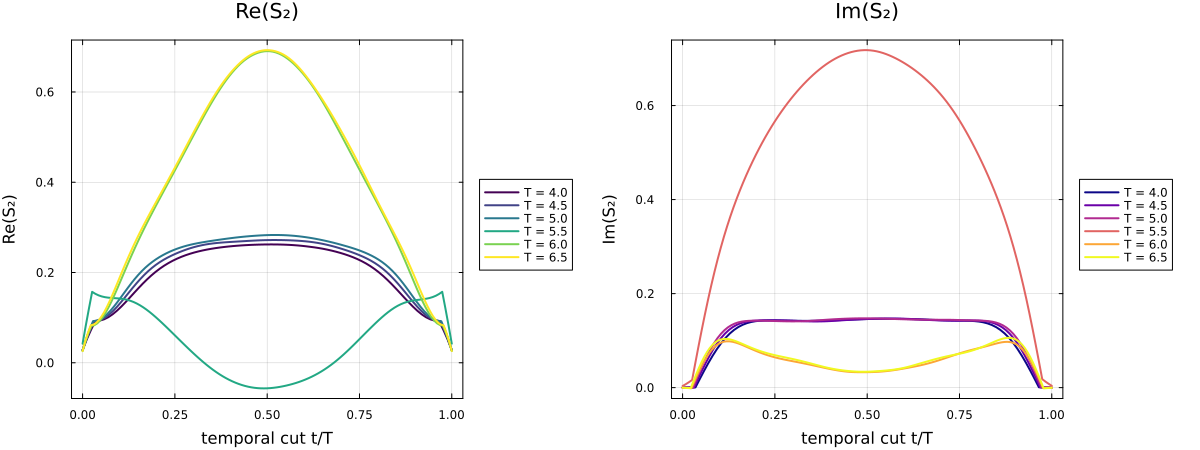

In [19]:
# Single-vector PM at δt=0.05 (nbeta=8 keeps β0=0.2). Same T list as the δt=0.1 sweep above.
mp = AlcarazParams(lambda=1.0, p=0.1)
plot_entropy_profiles(mp, [4.0, 4.5, 5.0, 5.5, 6.0, 6.5]; scheme=AlcarazVD2(), dt=0.05, nbeta=8,
                      maxdim=256, use_block_pm=false)

We observe that the dome breaks at the same physical
$T$, so the barrier is physical and not sensitive to the discretization.

In [20]:
# Quantitative T_crit: single-vector PM convergence vs (δt, T)
using Printf
Tgrid = [4.0, 4.5, 5.0, 5.5, 6.0, 6.5]
tcrit_results = Dict{Tuple{Float64,Int},Vector{NamedTuple}}()

for (dt_, nb_) in [(0.1, 4), (0.05, 8)]
    rows = NamedTuple[]
    for T in Tgrid
        r = run_pm_diagnosed(T; p=0.1, lambda=1.0, dt=dt_, maxdim=256, cutoff=1e-12,
                             eps_converged=1e-6, nbeta=nb_, MPO_alg="VD2",
                             itermax=5000, stuck_after=1000)
        maxchi = isempty(r.chi_hist) ? 0 : maximum(r.chi_hist)
        push!(rows, (T=T, reason=r.reason, final_ds=r.final_ds, maxchi=maxchi))
        GC.gc()
    end
    tcrit_results[(dt_, nb_)] = rows
end

# Display
for (dt_, nb_) in [(0.1, 4), (0.05, 8)]
    @printf("\n──── δt = %.2f  (nbeta=%d, β₀=%.1f) ────\n", dt_, nb_, nb_*dt_/2)
    @printf("  %-6s │ %-12s │ %-12s │ %-6s\n", "T", "reason", "final Δs", "maxχ")
    @printf("  ──────┼──────────────┼──────────────┼────────\n")
    for row in tcrit_results[(dt_, nb_)]
        mark = row.reason == "converged" ? " " : "⚠"
        @printf("  %-6.1f │ %-12s │ %-12.2e │ %-6d %s\n", row.T, row.reason, row.final_ds, row.maxchi, mark)
    end
end


┌ Warning: ProgressMeter by default refresh meters with additional information in IJulia via `IJulia.clear_output`, which clears all outputs in the cell. 
│  - To prevent this behaviour, do `ProgressMeter.ijulia_behavior(:append)`. 
│  - To disable this warning message, do `ProgressMeter.ijulia_behavior(:clear)`.
└ @ ProgressMeter ~/.julia/packages/ProgressMeter/N660J/src/ProgressMeter.jl:607

[PM LR|RTM] L=138, cutoff=1.0e-12, maxdim=256, normalize=overlap)  44%  ETA: 0:06:37 ( 0.14  s/it)
   Info: [2192]  chi=10 | ds=0.00036814098750387325 | <R|Rprev> = NaN

┌ Warning: PM Stuck after 1001/2193 steps | ds=0.00036485736422225967 | chi=10)
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/power_method/pm.jl:151



──── δt = 0.10  (nbeta=4, β₀=0.2) ────
  T      │ reason       │ final Δs     │ maxχ  
  ──────┼──────────────┼──────────────┼────────
  4.0    │ stuck        │ 2.44e-05     │ 11     ⚠


  4.5    │ converged    │ 9.41e-07     │ 12      
  5.0    │ stuck        │ 9.14e-05     │ 16     ⚠
  5.5    │ stuck        │ 1.77e-03     │ 20     ⚠
  6.0    │ stuck        │ 3.20e-04     │ 21     ⚠
  6.5    │ stuck        │ 2.98e-04     │ 26     ⚠

──── δt = 0.05  (nbeta=8, β₀=0.2) ────
  T      │ reason       │ final Δs     │ maxχ  
  ──────┼──────────────┼──────────────┼────────
  4.0    │ converged    │ 7.85e-07     │ 12      
  4.5    │ converged    │ 9.52e-07     │ 13      
  5.0    │ stuck        │ 3.29e-05     │ 14     ⚠
  5.5    │ stuck        │ 3.96e-03     │ 19     ⚠
  6.0    │ stuck        │ 9.07e-03     │ 23     ⚠
  6.5    │ stuck        │ 3.65e-04     │ 24     ⚠


### Block PM at $\delta t=0.05$

Finally the same $\delta t=0.05$, `nbeta=8` sweep through the **block** power method, to compare its
barrier onset against the $\delta t=0.1$ block-PM figure above.

[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=7|"S=1/2,Site") <-> (dim=2|id=7|"S=1/2,Site")', normdiff = 0.10171248785956927
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=751|"Link,l=1") <-> (dim=7|id=453|"Link,l=2"), normdiff = 0.7996732603851273
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=597|"S=1/2,Site") <-> (dim=2|id=597|"S=1/2,Site")', normdiff = 0.10171248785956927
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=937|"Link,l=1") <-> (di

┌ Warning: block PM did not strictly converge at T=4.0 (reason=stuck)
└ @ Main ~/Documents/masters/master-thesis-BSC/src/transverse_tools.jl:493
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices


┌ Warning: Tensor *not* symmetric (dim=2|id=592|"S=1/2,Site") <-> (dim=2|id=592|"S=1/2,Site")', normdiff = 0.10171248785956927
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=545|"Link,l=1") <-> (dim=7|id=781|"Link,l=2"), normdiff = 0.7996732603851273
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on physical(space) => bond(time) indices
┌ Warning: Tensor *not* symmetric (dim=2|id=933|"S=1/2,Site") <-> (dim=2|id=933|"S=1/2,Site")', normdiff = 0.10171248785956927
└ @ ITransverse ~/.julia/packages/ITransverse/8pmYI/src/ITenUtils/itensor_utils.jl:93
[ Info: Checking symmetry MPO tensor on bond(space) => phys(time) indices
┌ Warning: Tensor *not* symmetric (dim=7|id=279|"Link,l=1") <-> (dim=7|id=830|"Link,l=2"), normdiff = 1.0001624278247434
└ @ ITransverse ~/.j

┌ Warning: norm² is 2.387272744418135 + 5.773159728050814e-15im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1246


entropy profiles (AlcarazVD2)...  33%|██████▍            |  ETA: 0:10:26

...

┌ Warning: norm² is 2.4223879346321583e7 + 5.4016709327697754e-8im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1246
┌ Warning: log(norm²) is 0.8763091456544484 - 2.3879512668338774e-15im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1271


┌ Warning: norm² is 2.4228201017334662e7 + 5.774199962615967e-8im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1246
┌ Warning: norm² is 2.4188209616102412e7 + 5.4016709327697754e-8im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1246


┌ Warning: norm² is 1.8751070675471004e7 - 4.281173460185528e-8im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1246
┌ Warning: log(norm²) is 0.8821321279929607 + 2.332589696200558e-15im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1271


┌ Warning: norm² is 2.4202333084852375e7 - 5.4016709327697754e-8im, which is not real up to a relative tolerance of 2.220446049250313e-15 and an absolute tolerance of 2.220446049250313e-15. Taking the real part, which may not be accurate.
└ @ ITensorMPS ~/.julia/packages/ITensorMPS/fZDBz/src/abstractmps.jl:1246


entropy profiles (AlcarazVD2)... 100%|███████████████████| Time: 0:31:13


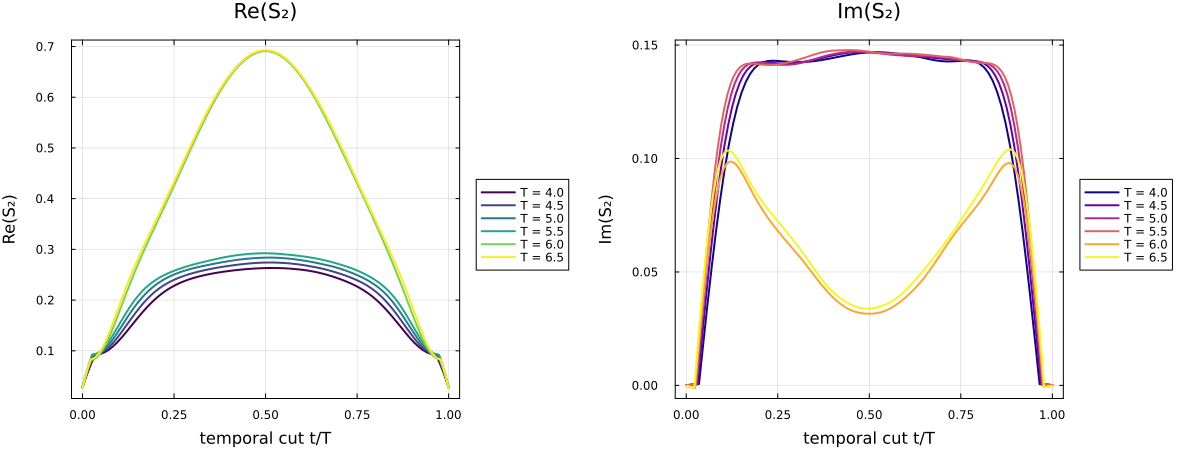

In [21]:
# HEAVY: block PM at δt=0.05 (nbeta=8). Compare the break point to the δt=0.1 block-PM figure above.
mp = AlcarazParams(lambda=1.0, p=0.1)
plot_entropy_profiles(mp, [4.0, 4.5, 5.0, 5.5, 6.0, 6.5]; scheme=AlcarazVD2(), dt=0.05, nbeta=8,
                      maxdim=256, use_block_pm=true, k_block=2)

### Does δt change the entropy *values*, not just where the barrier starts?

The sweep above showed that $T_{\rm crit}$ does not move with
$\delta t$. That leaves a related but different question: even before the barrier, does refining
$\delta t$ change the entropy *values* themselves, and how much does that refinement cost?

In [22]:
# Sweep the entropy profile over δt while keeping the UV regulator fixed at β0=0.2.
# This uses nbeta = 2β0/δt, so δt=0.1/0.05/0.025 corresponds to nbeta=4/8/16.
dt_entropy_cache = "../results/data/nb55_dt.jld2"
dt_grid = [
    (0.1, 4, [3.0, 4.0, 5.0]),
    (0.05, 8, [3.0, 4.0, 5.0]),
    (0.025, 16, [3.0, 4.0]),
]

dt_entropy_results = isfile(dt_entropy_cache) ? load(dt_entropy_cache, "D") : Dict{Any,Any}()

for (dt, nbeta, T_values) in dt_grid, T in T_values
    case_key = (dt, T)
    haskey(dt_entropy_results, case_key) && continue

    mp = AlcarazParams(lambda = 1.0, p = 0.1)
    walltime = @elapsed result = compute_entropies(
        mp,
        T;
        scheme = AlcarazVD2(),
        dt = dt,
        nbeta = nbeta,
        maxdim = 64,
        use_block_pm = true,
        k_block = 2,
        itermax = 2000,
        stuck_after = 150,
    )

    dt_entropy_results[case_key] = (
        ; dt,
        nbeta,
        T,
        re = result.re,
        im = result.im,
        peak = maximum(result.re),
        max_bond_dim = max(maxlinkdim(result.L), maxlinkdim(result.R)),
        n_time_steps = length(result.re) + 1,
        walltime,
    )

    jldsave(dt_entropy_cache; D = dt_entropy_results)
    GC.gc()
end

@info "δt sweep loaded" keys = sort(collect(keys(dt_entropy_results)))

┌ Info: δt sweep loaded
│   keys =
│    8-element Vector{Any}:
│     (0.025, 3.0)
│     (0.025, 4.0)
│     (0.05, 3.0)
│     (0.05, 4.0)
│     (0.05, 5.0)
│     (0.1, 3.0)
│     (0.1, 4.0)
└     (0.1, 5.0)


δt     T    | peak Re S₂ | max χ | Nₜ   | wall-time (s)


───────────┼────────────┼───────┼──────┼──────────────
0.100  3.0  | 0.2385     | 6     | 34   | 20.5
0.100  4.0  | 0.2640     | 8     | 44   | 49.0


0.100  5.0  | 0.2843     | 8     | 54   | 123.7
0.050  3.0  | 0.2378     | 6     | 68   | 40.2
0.050  4.0  | 0.2627     | 8     | 88   | 170.5
0.050  5.0  | 0.2837     | 8     | 108  | 226.2
0.025  3.0  | 0.2380     | 6     | 136  | 59.7
0.025  4.0  | 0.2629     | 7     | 176  | 176.4


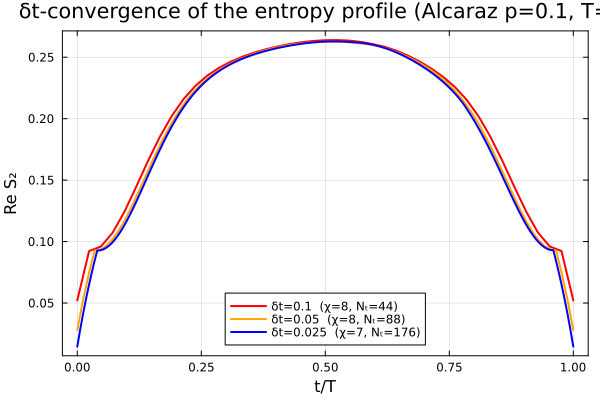

In [23]:
# Overlay the entropy profile at T=4 for the three δt values and print a compact cost/accuracy table.
profile_plot = plot(
    xlabel = "t/T",
    ylabel = "Re S₂",
    framestyle = :box,
    grid = true,
    legend = :bottom,
    title = "δt-convergence of the entropy profile (Alcaraz p=0.1, T=4)",
)

for (dt, color) in [(0.1, :red), (0.05, :orange), (0.025, :blue)]
    haskey(dt_entropy_results, (dt, 4.0)) || continue

    result = dt_entropy_results[(dt, 4.0)]
    cut_position = range(0, 1, length = length(result.re))

    plot!(
        profile_plot,
        cut_position,
        result.re;
        label = "δt=$dt  (χ=$(result.maxchi), Nₜ=$(result.nsteps))",
        lw = 2,
        color = color,
    )
end

savefig(profile_plot, "../results/imgs/nb55_dt_profiles.png")

println("δt     T    | peak Re S₂ | max χ | Nₜ   | wall-time (s)")
println("───────────┼────────────┼───────┼──────┼──────────────")
for (dt, nbeta, T_values) in dt_grid, T in T_values
    haskey(dt_entropy_results, (dt, T)) || continue

    result = dt_entropy_results[(dt, T)]
    @printf(
        "%-6.3f %-4.1f | %-10.4f | %-5d | %-4d | %.1f\n",
        dt,
        T,
        result.peak,
        result.maxchi,
        result.nsteps,
        result.walltime,
    )
end

profile_plot

The entropy values barely move, but the cost does (and a lot)! Refining $\delta t$ from $0.1\to0.05\to0.025$
barely changes the peak entropy at $T=4$, while the
temporal chain length doubles at each step ($N_t=44\to88\to176$) and the wall-time grows sharply ($49\to171\to176\,$s). Combined with the earlier finding that $T_{\rm crit}$ itself does not move
with $\delta t$, this confirms the entanglement barrier is a genuinely physical feature of the
model (not a discretization artefact) and that refining $\delta t$ past $0.05$ buys essentially
nothing for this observable while costing substantially more.

## Takeaways

- The generalized Rényi-2 temporal entropy $S_2^{\rm gen}(t)=-\log\mathrm{Tr}(\mathcal{T}_t^2)$
  is the cost-controlling observable of the transverse method, computed from the RTM built out of
  the two power-method boundaries.
- Its profile has the conformal chord shape and grows logarithmically with $T$ (signature CFT prediction quantified in notebooks 6–7).
- The single-vector power method stops converging once the transfer-matrix gap closes ($T\gtrsim5$
  for $p=0.1$), completely destroying the CFT prediction for the entropy profiles. This is the entanglement barrier but in the rotated picture.
- The block power method (`use_block_pm=true`) keeps the left/right eigenvectors well-separated
  through the degeneracy and recovers the conformal dome to larger $T$. The alternative (tracking
  only the eigenvalue $\lambda_0$) is robust but discards the profile (see notebooks 5, 7).
- The physical-gap sweep is genuinely erratic for $p=0.3,0.5$ (open question).
- The barrier is a physical time, not a discretization artefact: confirmed two ways: $T_{\rm crit}$ itself doesn't move with $\delta t$, and the entropy *values* barely change while the cost grows sharply.
- VD2 is the reliable kernel for the NNN model.